# Практическое задание «Поиск выбросов»

## Шаблон для выполнения

### Часть 1. Выявление и визуализация выбросов

В этом задании вы будете работать с реальным датасетом, в котором содержится информация о более чем 50 000 бриллиантах. У каждого бриллианта есть несколько характеристик:

• **carat**: вес бриллианта. Более крупные бриллианты, как правило, дороже.

• **cut**: качество огранки. Измеряется по градации качества: "Fair", "Good", "Very Good",
"Premium", "Ideal".

• **color**: оценка цвета бриллианта. Ранжируется от "J" (худшая) to "D" (лучшая).

• **clarity**: чистота бриллианта. Описывается кодом (по возрастанию качества): "I1" (худшая), "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF" (лучшая).

• **price**: цена бриллианта в долларах США.

Измерения:

• **x, y, z**, длина, ширина и глубина в мм

• Глубина и площадка - это отношения (в %)

• **depth** = 2 z / (x+y)

• **table** = ширина верха / наибольшая ширина

![image.png](https://u.netology.ru/backend/uploads/lms/content_assets/file/14718/tg_image_378460715.png)

In [1]:
import seaborn as sns
diamonds = sns.load_dataset("diamonds", cache=True, data_home=None)
diamonds.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


1.1. Загрузите файл `diamonds.csv` из библиотеки seaborn. Проведите предварительный анализ:

 - Получите базовые статистики датафрейма.
 - Найдите топ-3 столбца с наибольшим количеством пропусков.
 - Посмотрите уникальные значения в столбцах `carat`, `depth`, `table` и `price`. Есть ли там странные значения?
 - Для каждой из четырх переменных постройте гистограмму и ящик с усами (boxplot).

*Объясните природу выбросов: являются ли они естественными или синтетическими?*

Размер датасета: (53940, 10)
         missing  missing_%     dtype
carat          0        0.0   float64
cut            0        0.0  category
color          0        0.0  category
clarity        0        0.0  category
depth          0        0.0   float64
table          0        0.0   float64
price          0        0.0     int64
x              0        0.0   float64
y              0        0.0   float64
z              0        0.0   float64
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     61.800000     57.000000   2401.000000      5.700000   


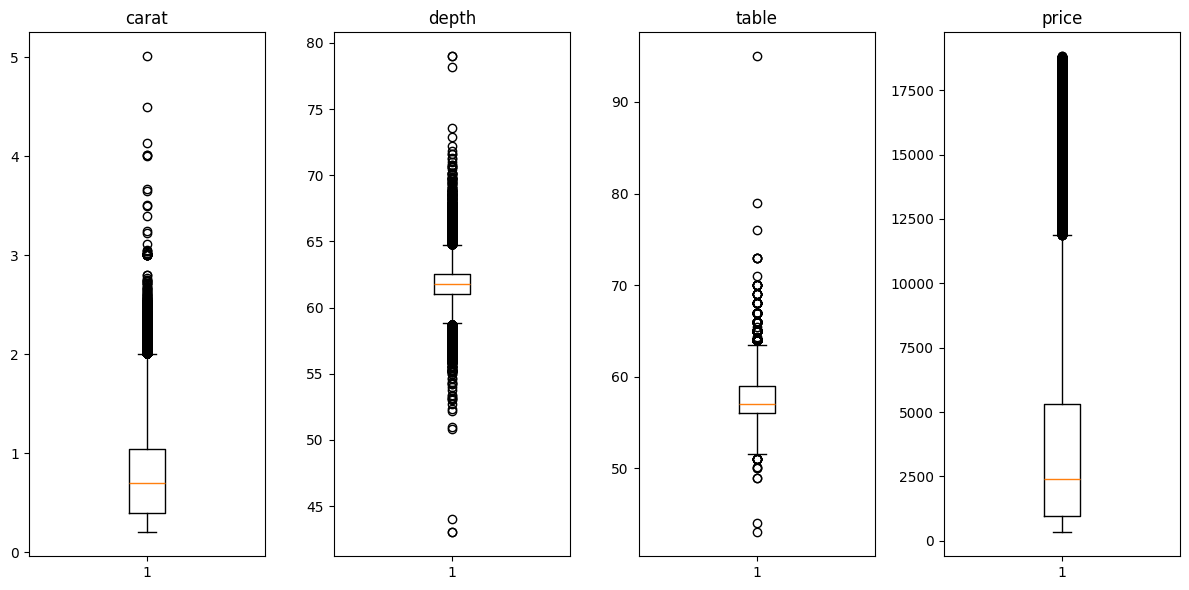

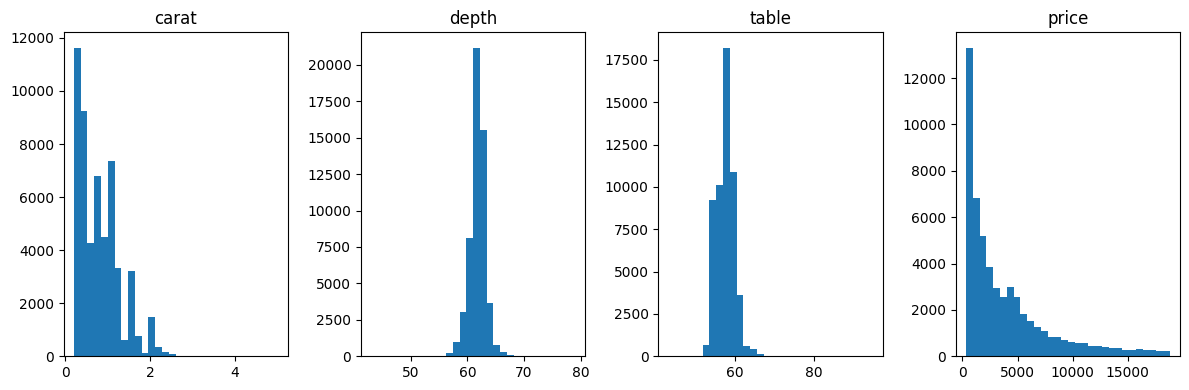

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

diamonds = sns.load_dataset("diamonds") # загружаем датасет

print("Размер датасета:", diamonds.shape) # выводим размер

# пропуски и типы данных
info = pd.DataFrame({"missing":(diamonds.isna().sum()),
                     "missing_%": (diamonds.isna().mean() * 100).round(2),
                     "dtype": diamonds.dtypes})
print(info.sort_values("missing_%", ascending=False)) 

print(diamonds.describe())

# Загрузите данные и проведите первичный анализ
# Уникальные значения признаков
unical = ["carat","depth","table","price"]
for uni in unical:
    print(f"\nУникальные {uni}:")
    print(sorted(diamonds[uni].unique().tolist()))

# ящик с усами
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(12, 6))
for ax, uni in zip(axs, unical):
    ax.boxplot(diamonds[uni])
    ax.set_title(uni)
plt.tight_layout()
plt.show()

# гистограммы
fig, axs = plt.subplots(1, 4, figsize=(12, 4))

for ax, uni in zip(axs, unical):
    ax.hist(diamonds[uni], bins=30)
    ax.set_title(uni)

plt.tight_layout()
plt.show()

In [3]:
# Выводы: несмотря на то, что ящики с усами, построенные для данных 4 признаков, показывают нам подозрения на выбросы:
# carat - значения от 2 находятся выше верхнего квартиля
# depth - значения до 58 и от 65 находятся ниже и выше нижнего и верхнего квартилей соответственно
# table - значения до 51 и от 62 находятся ниже и выше нижнего и верхнего квартилей соответственно
# price - значения от 12000 находятся выше верхнего квартиля

# Однако исходя из бизнес логики мы можем понять, что:
# - внеквартильные значения веса не являются выбросами (данные значения указывают крупные образцы бриллиантов)
# - внеквартильные значения глубины не являются выбросами. Они лишь указывают различное соотношение габаритов бриллианта и находятся в пределах от 40 до 100%
# - внеквартильные значения площадки не являются выбросами. Они лишь указывают различное соотношение габаритов бриллианта и находятся в пределах от 40 до 95%
# - внеквартильные значения цены не являются выбросами. Очевидно наличие дорогих образцов.

#То есть я предполагаю, что единственно-возможные "выбросы" для данных параметров - это значения, принадлежащие другой категории. Как в примере со стоимостью машин, где в списке марок среднего сегмента появляется ferrari. Это не выброс с точки зрения данных, однако для повышения качества обучения модели есть необходимость выделить подобные элементы в отдельную категорию.

1.2. Обучите регрессионную модель предсказания цены бриллианта в зависимости от значений веса (в каратах), площадки и глубины.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)
import numpy as np

# Обучите линейную модель
y = diamonds["price"]
X = diamonds[["carat","depth","table"]]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

model = LinearRegression() #создаем модель
model.fit(X_train, y_train) #обучаем по значениям целевой переменной и параметрам

# Train
y_pred_train = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Test
y_pred_test = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

results = pd.DataFrame({
    "Train": [mse_train, rmse_train, mae_train, r2_train],
    "Test":  [mse_test, rmse_test, mae_test,  r2_test]
},
index=["MSE", "RMSE", "MAE", "R2"])

results.style.format({"Train": "{:,.4f}","Test": "{:,.4f}"})

,Train,Test
MSE,"2,327,608.2809","2,333,883.1793"
RMSE,"1,525.6501","1,527.7052"
MAE,995.8807,994.7367
R2,0.8538,0.8532


### Шаг 2. Обработка признаков

2.1. Реализуйте модельный метод для анализа выбросов.
- Постройте линейную модель для описания данных
- Визуализируйте предсказания

*Определите выбросы по графику предсказаний. Где модель ошибается сильнее всего?*

In [5]:
import numpy as np


# Обучите линейную модель
y = diamonds["price"]
X = diamonds[["carat"]]
# X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X, y)

# Получите предсказания
y_pred = model.predict(X)

# Получите остатки
residuals = y-y_pred

# Установите пороговое значение
# Общепринятое пороговое значение - три стандартных отклонения
threshold = 3*residuals.std()
# Определите выбросы
# (воспользуйтесь методом np.abs для получения значения по модулю)
outliers = np.abs(residuals) > threshold
diamonds["outlier_carat_3std"] = outliers.astype(int)
percent_outlier_carat_3std=(diamonds["outlier_carat_3std"].sum())/(diamonds["carat"].count())*100
print(f"% Выбросов: {percent_outlier_carat_3std:.2f}%")

% Выбросов: 2.24%


Визуализируйте предсказанную линию на графике и определите выбросы.

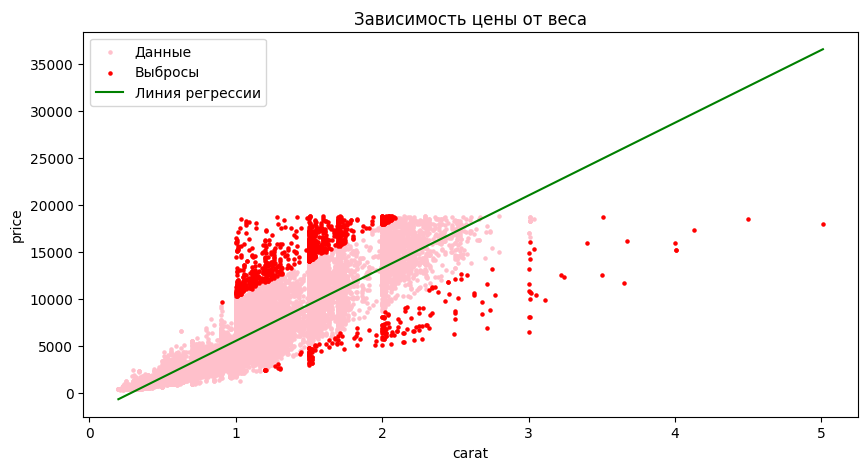

In [6]:
import matplotlib.pyplot as plt

# Ваш код здесь

plt.figure(figsize=(10,5))

# Обычные точки
plt.scatter(X[~outliers], y[~outliers], s=5, label="Данные", color='pink')

# Выбросы
plt.scatter(X[outliers], y[outliers], s=5, label="Выбросы", color='red' )

# Линия регрессии
sort_idx = X["carat"].argsort()
X_sorted = X["carat"].iloc[sort_idx]
y_pred_sorted = y_pred[sort_idx]

plt.plot(X_sorted, y_pred_sorted, label="Линия регрессии", color="green")

plt.title("Зависимость цены от веса")
plt.xlabel("carat")
plt.ylabel("price")
plt.legend()
plt.show()

% Выбросов: 2.23%


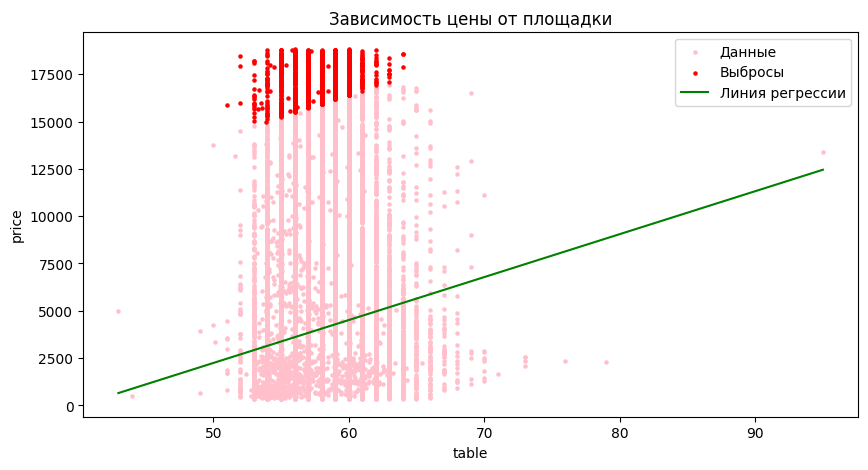

In [7]:
#Теперь делаю то же самое для двух других признаков (площадки и глубины)
# Площадка table
y = diamonds["price"]
X = diamonds[["table"]]
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y-y_pred
threshold = 3*residuals.std()
outliers = np.abs(residuals) > threshold
diamonds["outlier_table_3std"] = outliers.astype(int)
percent_outlier_table_3std=(diamonds["outlier_table_3std"].sum())/(diamonds["table"].count())*100
print(f"% Выбросов: {percent_outlier_table_3std:.2f}%")
plt.figure(figsize=(10,5))
plt.scatter(X[~outliers], y[~outliers], s=5, label="Данные", color='pink')
plt.scatter(X[outliers], y[outliers], s=5, label="Выбросы", color='red' )
sort_idx = X["table"].argsort()
X_sorted = X["table"].iloc[sort_idx]
y_pred_sorted = y_pred[sort_idx]
plt.plot(X_sorted, y_pred_sorted, label="Линия регрессии", color="green")
plt.title("Зависимость цены от площадки")
plt.xlabel("table")
plt.ylabel("price")
plt.legend()
plt.show()

% Выбросов: 2.22%


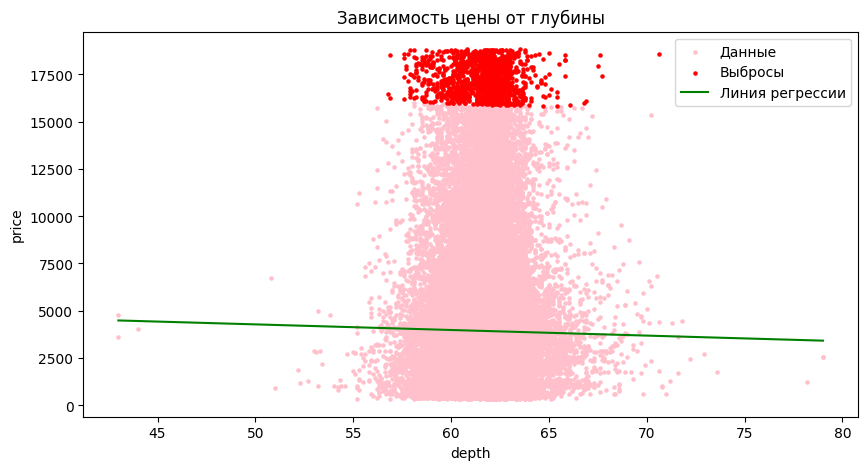

In [8]:
# Глубина depth 
y = diamonds["price"]
X = diamonds[["depth"]]
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y-y_pred
threshold = 3*residuals.std()
outliers = np.abs(residuals) > threshold
diamonds["outlier_depth_3std"] = outliers.astype(int)
percent_outlier_depth_3std=(diamonds["outlier_depth_3std"].sum())/(diamonds["depth"].count())*100
print(f"% Выбросов: {percent_outlier_depth_3std:.2f}%")
plt.figure(figsize=(10,5))
plt.scatter(X[~outliers], y[~outliers], s=5, label="Данные", color='pink')
plt.scatter(X[outliers], y[outliers], s=5, label="Выбросы", color='red' )
sort_idx = X["depth"].argsort()
X_sorted = X["depth"].iloc[sort_idx]
y_pred_sorted = y_pred[sort_idx]
plt.plot(X_sorted, y_pred_sorted, label="Линия регрессии", color="green")
plt.title("Зависимость цены от глубины")
plt.xlabel("depth")
plt.ylabel("price")
plt.legend()
plt.show()

In [9]:
# Теперь применим тот же метод, только обучив модель на 3 признаках (без визуализации)
y = diamonds["price"]
X = diamonds[["carat","depth","table"]]
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = y-y_pred
threshold = 3*residuals.std()
outliers = np.abs(residuals) > threshold
diamonds["3std"] = outliers.astype(int)
percent_outlier_all_3std=(diamonds["3std"].sum())/(diamonds["price"].count())*100
print(f"% Выбросов: {percent_outlier_depth_3std:.2f}%")

% Выбросов: 2.22%


2.2. Реализуйте метод опорных векторов (SVM) для поиска выбросов.

% Выбросов: 2.00%


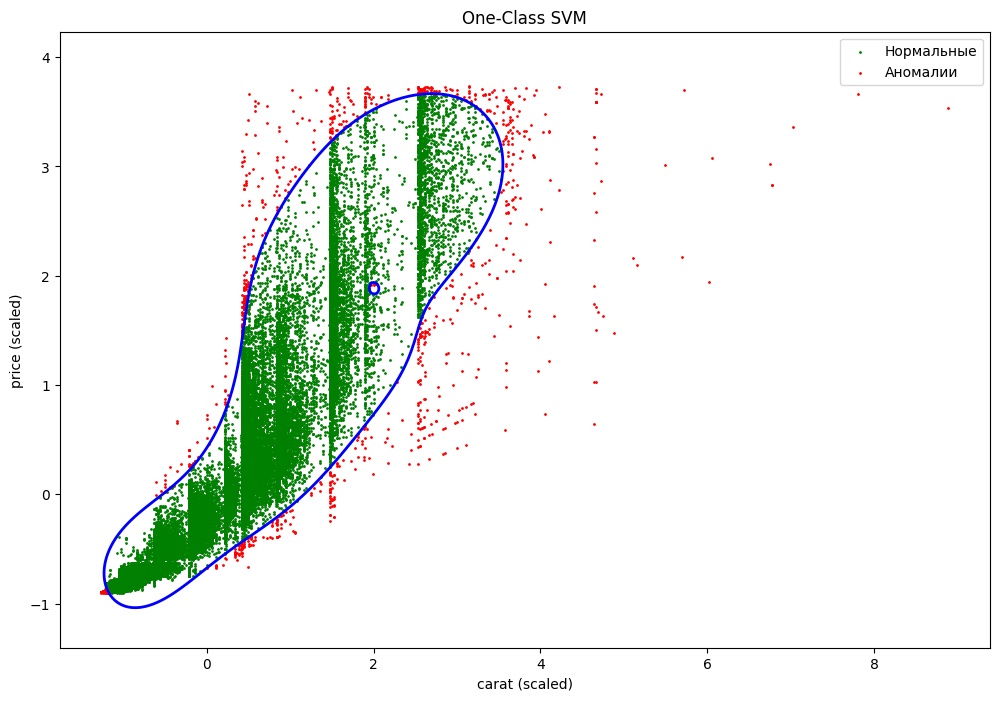

In [10]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler


# Каждый бриллиант описан двумя координатами:весом и реальной ценой
X = diamonds[["carat", "price"]]

# Приводим carat и price к сопоставимому масштабу
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


model = OneClassSVM(kernel="rbf",gamma="scale",nu=0.02) # создаем модель
model.fit(X_scaled) # Обучаем

predictions = model.predict(X_scaled) # для каждой строки получаем: 1 - нормальная точка, -1 - выброс

diamonds["catat_one_class_svm"] = predictions == -1 # создаём удобный булев столбец
percent_outlier_carat_3SVM=((predictions == -1).sum())/(diamonds["depth"].count())*100
print(f"% Выбросов: {percent_outlier_carat_3SVM:.2f}%")

# график
xx, yy = np.meshgrid(
    np.linspace(X_scaled[:, 0].min() - 0.5,
                X_scaled[:, 0].max() + 0.5,
                300),

    np.linspace(X_scaled[:, 1].min() - 0.5,
                X_scaled[:, 1].max() + 0.5,
                300))

# для каждой точки сетки вычисляем значение функции
Z = model.decision_function(
    np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(12,8))

# граница нормальной области
plt.contour(
    xx,
    yy,
    Z,
    levels=[0],
    linewidths=2,
    colors="blue")

# нормальные точки
plt.scatter(
    X_scaled[predictions == 1, 0],
    X_scaled[predictions == 1, 1],
    color="green",
    s=1,
    label="Нормальные")
plt.scatter(
    X_scaled[predictions == -1, 0],
    X_scaled[predictions == -1, 1],
    color="red",
    s=1,
    label="Аномалии")
plt.xlabel("carat (scaled)")
plt.ylabel("price (scaled)")
plt.title("One-Class SVM")
plt.legend()
plt.show()

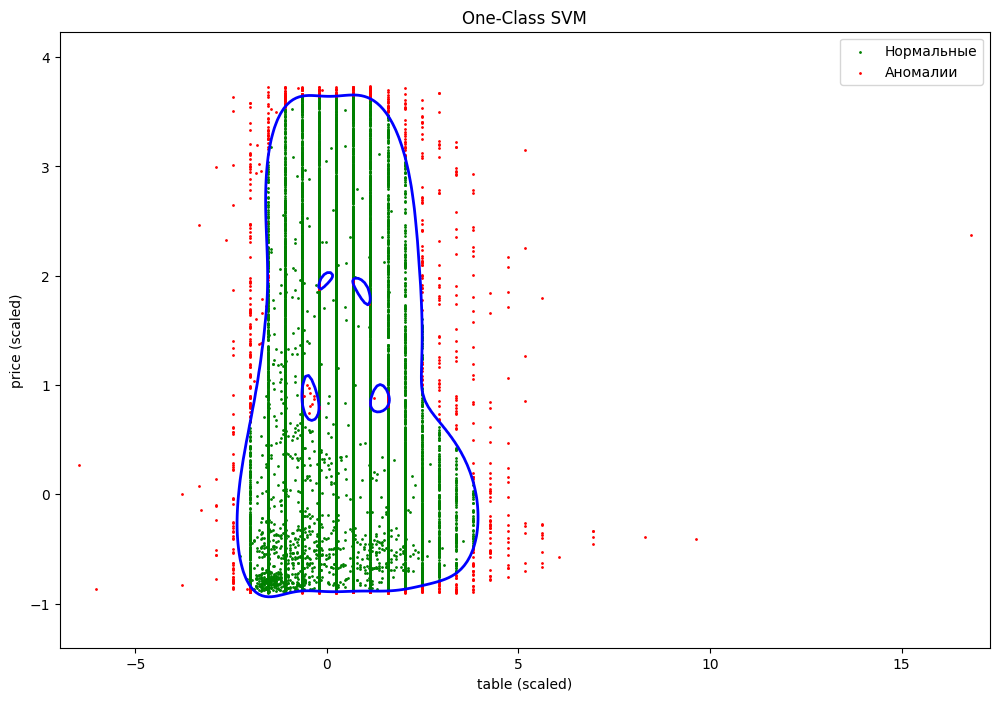

In [11]:
X = diamonds[["table", "price"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = OneClassSVM(kernel="rbf",gamma="scale",nu=0.02)
model.fit(X_scaled) 
predictions = model.predict(X_scaled)
diamonds["table_one_class_svm"] = predictions == -1 # Создаём удобный булев столбец
xx, yy = np.meshgrid(
    np.linspace(X_scaled[:, 0].min() - 0.5,
                X_scaled[:, 0].max() + 0.5,
                300),

    np.linspace(X_scaled[:, 1].min() - 0.5,
                X_scaled[:, 1].max() + 0.5,
                300))

Z = model.decision_function(
    np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(12,8))

plt.contour(
    xx,
    yy,
    Z,
    levels=[0],
    linewidths=2,
    colors="blue")

plt.scatter(
    X_scaled[predictions == 1, 0],
    X_scaled[predictions == 1, 1],
    color="green",
    s=1,
    label="Нормальные")
plt.scatter(
    X_scaled[predictions == -1, 0],
    X_scaled[predictions == -1, 1],
    color="red",
    s=1,
    label="Аномалии")
plt.xlabel("table (scaled)")
plt.ylabel("price (scaled)")
plt.title("One-Class SVM")
plt.legend()
plt.show()

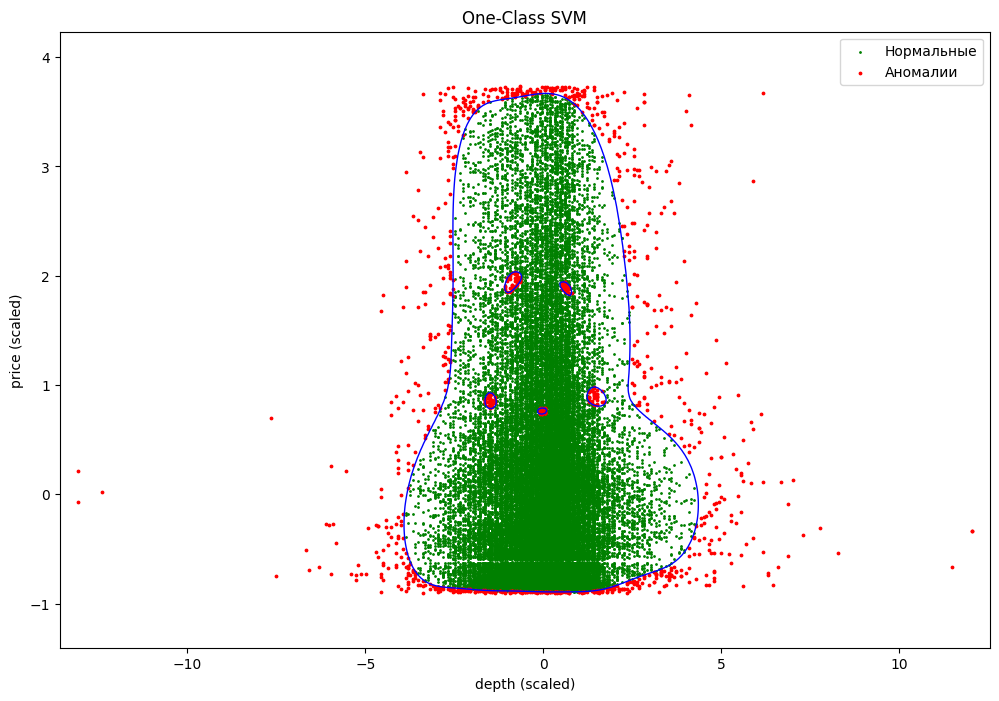

In [12]:
X = diamonds[["depth", "price"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = OneClassSVM(kernel="rbf",gamma="scale",nu=0.02)
model.fit(X_scaled) 
predictions = model.predict(X_scaled)
diamonds["depth_one_class_svm"] = predictions == -1 # Создаём удобный булев столбец
xx, yy = np.meshgrid(
    np.linspace(X_scaled[:, 0].min() - 0.5,
                X_scaled[:, 0].max() + 0.5,
                300),

    np.linspace(X_scaled[:, 1].min() - 0.5,
                X_scaled[:, 1].max() + 0.5,
                300))

Z = model.decision_function(
    np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(12,8))

plt.contour(
    xx,
    yy,
    Z,
    levels=[0],
    linewidths=1,
    colors="blue")

plt.scatter(
    X_scaled[predictions == 1, 0],
    X_scaled[predictions == 1, 1],
    color="green",
    s=1,
    label="Нормальные")
plt.scatter(
    X_scaled[predictions == -1, 0],
    X_scaled[predictions == -1, 1],
    color="red",
    s=3,
    label="Аномалии")
plt.xlabel("depth (scaled)")
plt.ylabel("price (scaled)")
plt.title("One-Class SVM")
plt.legend()
plt.show()

In [ ]:
# Также мы можем применить данный метод и ко всем 3 признакам. Просто в таком случае не сможем визуализировать результат в двумерном пространстве
X = diamonds[["carat","depth","table","price"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = OneClassSVM(kernel="rbf",gamma="scale",nu=0.02) # создаем модель
model.fit(X_scaled) # Обучаем

predictions = model.predict(X_scaled) # Для каждой строки получаем: 1 - нормальная точка, -1 - выброс
diamonds["ocsvm"] = predictions == -1 # Создаём удобный булев столбец


One-Class SVM
Выбросов: 1109
Доля: 2.06 %


2.3. Реализуйте алгоритм Isolation Forest

In [14]:
from sklearn.ensemble import IsolationForest

X = diamonds[["carat", "depth", "table", "price"]]

model_if = IsolationForest(contamination=0.02, random_state=42)

predictions_if = model_if.fit_predict(X)

diamonds["if"] = predictions_if == -1

2.4. Сравните работу методов: какой из них предпочтительнее для вашей задачи?

2.5. Удалите выбросы выбранным методом

In [15]:
def delete_and_fit (delete):
    diamonds_clean=diamonds[diamonds[delete] != 1]
    y = diamonds_clean["price"]
    X = diamonds_clean[["carat","depth","table"]]

    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

    model = LinearRegression() #создаем модель
    model.fit(X_train, y_train) #обучаем по значениям целевой переменной и параметрам

    # Train
    y_pred_train = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    # Test
    y_pred_test = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    results = pd.DataFrame(
        {"Train": [mse_train, rmse_train, mae_train, r2_train],
            "Test": [mse_test, rmse_test, mae_test, r2_test]},
        index=["MSE", "RMSE", "MAE", "R²"])

    return results

from IPython.display import display

print("До удаления выбросов")
display(results.style.format("{:,.4f}"))

result_3std = delete_and_fit("3std")
result_svm = delete_and_fit("ocsvm")
result_iforest = delete_and_fit("if")



print("После удаления выбросов по правилу 3 стандартных отклонения")
display(result_3std.style.format("{:,.4f}"))

print("После удаления выбросов One-Class SVM")
display(result_svm.style.format("{:,.4f}"))

print("После удаления выбросов Isolation Forest")
display(result_iforest.style.format("{:,.4f}"))


До удаления выбросов


,Train,Test
MSE,"2,327,608.2809","2,333,883.1793"
RMSE,"1,525.6501","1,527.7052"
MAE,995.8807,994.7367
R2,0.8538,0.8532


После удаления выбросов по правилу 3 стандартных отклонения


,Train,Test
MSE,"1,458,345.7384","1,410,814.9543"
RMSE,"1,207.6199","1,187.7773"
MAE,857.9695,844.4770
R²,0.8935,0.8918


После удаления выбросов One-Class SVM


,Train,Test
MSE,"2,011,158.9532","1,981,979.5653"
RMSE,"1,418.1534","1,407.8280"
MAE,968.8451,961.8746
R²,0.8680,0.8665


После удаления выбросов Isolation Forest


,Train,Test
MSE,"2,078,814.4141","2,092,361.2092"
RMSE,"1,441.8094","1,446.4996"
MAE,951.1396,954.8328
R²,0.8491,0.8469


### Часть 3. Обучение

Снова обучите регрессионную модель предсказания цены бриллианта в зависимости от значений веса (в каратах), площадки и глубины - после улучшения признаков. Как поменялось качество предсказания после удаления выбросов?

In [16]:
# Выполнил выше
# Сравним, какое количество выбросов определили все 3 метода, 2 метода или только 1 метод
diamonds["result"]= diamonds["3std"] + diamonds["ocsvm"] + diamonds["if"]
diamonds["result"].value_counts()


result
0    51398
1     1830
2      582
3      130
Name: count, dtype: int64

### Итоги (рефлексия)

Напишите выводы (5–7 предложений):

1. Какой метод поиска выбросов вы сочли наиболее предпочтительным?
2. Как сильно выросла точность модели после очистки?

**Ваши выводы:**
1. Я не очень понял один момент, который требовался в данном задании. 
   Нас просили показать графически, как выглядит выбор выбросов в случае применения модели линейной регрессии и дальнейшем выделении значений, удаленных от линии предсказаний на расстояние, равное или большее трем стандартным отклонениям. То же же самое для метода определяющих векторов. Для того, чтобы построить графическое отображение, мы выбирали только два массива значений (целевая переменная и вес), иначе мы бы получили гиперповерхность в многомерном пространстве, однако "сухой" отбор выбросов в каждом методе мы производили на основании всех указанных признаков (вес, глубина, площадка). 
     
      Как на основании получившихся выбросов для каждого метода нам можно было сделать выбор в пользу какого-либо метода перед тем как обучать модель на датасете без выбросов? По количеству выбросов нельзя, так как по сути мы их сами же и задавали. 
В моем понимании именно этот показатель (улучшение метрик предсказаний модели) и является основополагающим при выборе методики выбора выбросов. Или я не прав? 
1. Если сравнивать оптимальный метод (определение выбросов как значений, удаленных на расстояние 3 и более стандартных отклонений от предсказаний линейной регрессии) с первоначальным датасетом, то MSE уменьшилась примерно на 37%, MAE уменьшилась примерно на 14%, R2 увеличился примерно на 4%